# BIAS MDS — Magnitude difference heatmaps (Block 2)

Agent×agent heatmaps laid out as a **2×5 grid**: rows are the video city
(**Videos of LIMA** on top, **Videos of NYC** on bottom) and columns are the
**5 questions** (Q6–Q10). Cell `(A, B)` is the **average over that city's videos**
of the magnitude difference `|rating_A − rating_B|` for that question.

- Only the **numeric rating** is used (`ANSWER` converted to a number).
- Only **one repetition** (`REPETITION == 1`), since the magnitude bias does not
  depend on intra-agent variance.
- **NaN handling**: if for a given video one of the two agents answered `nan`,
  that video is skipped *for that pair only* (`np.nanmean`); the remaining videos
  still count. This way NaNs do not void the whole cell, and no values are
  fabricated.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize


def blended_grid(ax, data, cmap, vmin, vmax, width=0.15, res=24, alpha=1.0):
    """Costuras internas del heatmap con gradiente tri-punto: A -> blanco -> B.

    Cada frontera entre dos celdas se pinta como una banda perpendicular: del lado
    de A su color, blanco estático al medio, y el color de B del otro lado. Se dibuja
    como UNA capa raster por subplot (transparente en el interior de las celdas), así
    se ve idéntico en PNG y SVG sin inflar el SVG.

    width: ancho de la banda en fracción de celda (1 celda = 1 unidad de dato).
    res:   px por celda de la capa raster (más alto = gradiente más suave, capa más pesada).
    """
    data = np.asarray(data, float)
    nrows, ncols = data.shape
    norm = Normalize(vmin, vmax)
    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    cell = np.asarray(cmap(norm(np.ma.masked_invalid(data))))  # (nrows, ncols, 4)
    white = np.array([1.0, 1.0, 1.0, 1.0])

    H, W = nrows * res, ncols * res
    out = np.zeros((H, W, 4))                       # capa transparente
    xs = (np.arange(W) + 0.5) / res                 # x en coords de dato [0, ncols]
    ys = (np.arange(H) + 0.5) / res                 # y en coords de dato [0, nrows]
    XX, YY = np.meshgrid(xs, ys)
    half = width / 2.0

    def tri(t, A, B):
        # t in [0,1]: 0 -> A, 0.5 -> blanco, 1 -> B
        t = t[..., None]
        lo = (1 - 2 * t) * A + (2 * t) * white      # tramo A -> blanco
        hi = (2 - 2 * t) * white + (2 * t - 1) * B  # tramo blanco -> B
        return np.where(t <= 0.5, lo, hi)

    nx = np.round(XX); dV = np.abs(XX - nx)         # frontera vertical más cercana
    ny = np.round(YY); dH = np.abs(YY - ny)         # frontera horizontal más cercana
    vmask = (dV <= half) & (nx >= 1) & (nx <= ncols - 1)
    hmask = (dH <= half) & (ny >= 1) & (ny <= nrows - 1)
    use_v = vmask & (~hmask | (dV <= dH))           # en esquinas: gana la frontera más cercana
    use_h = hmask & (~vmask | (dH < dV))

    rid = np.clip(YY.astype(int), 0, nrows - 1)
    cid = np.clip(XX.astype(int), 0, ncols - 1)

    if use_v.any():                                  # A = celda izquierda, B = celda derecha
        cb = nx.astype(int); ca = cb - 1
        A = cell[rid, np.clip(ca, 0, ncols - 1)]
        B = cell[rid, np.clip(cb, 0, ncols - 1)]
        t = np.clip((XX - (nx - half)) / width, 0, 1)
        out[use_v] = tri(t, A, B)[use_v]
    if use_h.any():                                  # A = celda de arriba, B = celda de abajo
        rb = ny.astype(int); ra = rb - 1
        A = cell[np.clip(ra, 0, nrows - 1), cid]
        B = cell[np.clip(rb, 0, nrows - 1), cid]
        t = np.clip((YY - (ny - half)) / width, 0, 1)
        out[use_h] = tri(t, A, B)[use_h]

    out[..., 3] *= alpha
    ax.imshow(out, extent=(0, ncols, nrows, 0), origin="upper",
              interpolation="bilinear", zorder=5)

In [3]:
%cd ..

f:\robusto\vqa_analysis


In [4]:
# --- LOAD: Block 2, repetition 1, numeric rating ---
from pipeline.utils.metrics import get_ordered_agents, display_agent_names, to_numeric, get_video_region
from pipeline.style import DIVERGING_CMAP

# keep_default_na=False -> "nan" comes in as a string; to_numeric turns it into explicit np.nan.
df = pd.read_csv("data/r2_cleaned.csv", keep_default_na=False)
df["REPETITION"] = df["REPETITION"].astype(int)
df["QUESTION_NUM"] = df["QUESTION_NUM"].astype(int)
df["BLOCK"] = df["BLOCK"].astype(int)

df_b2 = df[(df["BLOCK"] == 2) & (df["REPETITION"] == 1)].copy()
df_b2["ANSWER"] = df_b2["ANSWER"].apply(to_numeric)        # numeric; unparseable answers -> NaN
df_b2["VIDEO_REGION"] = df_b2["VIDEO"].apply(get_video_region)  # "Videos of LIMA" / "Videos of NYC"

agents = get_ordered_agents(df_b2["AGENT"].unique())          # VLMs + humans, repo's stable order
questions = sorted(df_b2["QUESTION_NUM"].unique())            # [6, 7, 8, 9, 10]
regions = ["Videos of LIMA", "Videos of NYC"]                 # LIMA on top, NYC on bottom

n_nan = df_b2["ANSWER"].isna().sum()
print(f"Agents: {len(agents)} | Questions: {questions} | Regions: {regions} | Rows: {len(df_b2)} | NaN in ANSWER: {n_nan}")

Agents: 30 | Questions: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] | Regions: ['Videos of LIMA', 'Videos of NYC'] | Rows: 3000 | NaN in ANSWER: 2


In [5]:
#checking the nans
nan_rows = df_b2[df_b2["ANSWER"].isna()]
print(nan_rows[["AGENT", "QUESTION_NUM", "VIDEO_REGION","VIDEO"]])

                  AGENT  QUESTION_NUM    VIDEO_REGION         VIDEO
56900  Perception-LM-8B             6  Videos of LIMA   Robusto2_37
62500  Perception-LM-8B             6   Videos of NYC  Robusto2_181


In [6]:
# --- COMPUTE: agent×agent matrix of average |diff| per (city, question) ---
def magnitude_diff_matrix(sub: pd.DataFrame, agents: list[str]) -> np.ndarray:
    """For one (city, question): mean_v |rating_A(v) - rating_B(v)| over shared videos.

    Pivots videos×agents; for each pair, np.nanmean of |diff| skips the videos
    where either agent answered NaN (pairs with no shared video stay NaN).
    """
    mat = sub.pivot_table(index="VIDEO", columns="AGENT", values="ANSWER", aggfunc="mean")
    mat = mat.reindex(columns=agents)
    A = mat.to_numpy()                       # (n_videos, n_agents)
    # |A_i - A_j| vectorized: (videos, agents, 1) - (videos, 1, agents)
    diff = np.abs(A[:, :, None] - A[:, None, :])  # (videos, agents, agents)
    with np.errstate(invalid="ignore"):
        counts = (~np.isnan(diff)).sum(axis=0)
        M = np.where(counts > 0, np.nanmean(diff, axis=0), np.nan)
    return M

# matrices[(region, question)] -> agent×agent matrix
matrices = {
    (region, q): magnitude_diff_matrix(
        df_b2[(df_b2["VIDEO_REGION"] == region) & (df_b2["QUESTION_NUM"] == q)], agents
    )
    for region in regions
    for q in questions
}

# Shared color scale so cities and questions can be compared against each other.
vmax = float(np.nanmax([np.nanmax(M) for M in matrices.values()]))
print(f"Average |diff| range: 0 .. {vmax:.2f}")

Average |diff| range: 0 .. 6.20


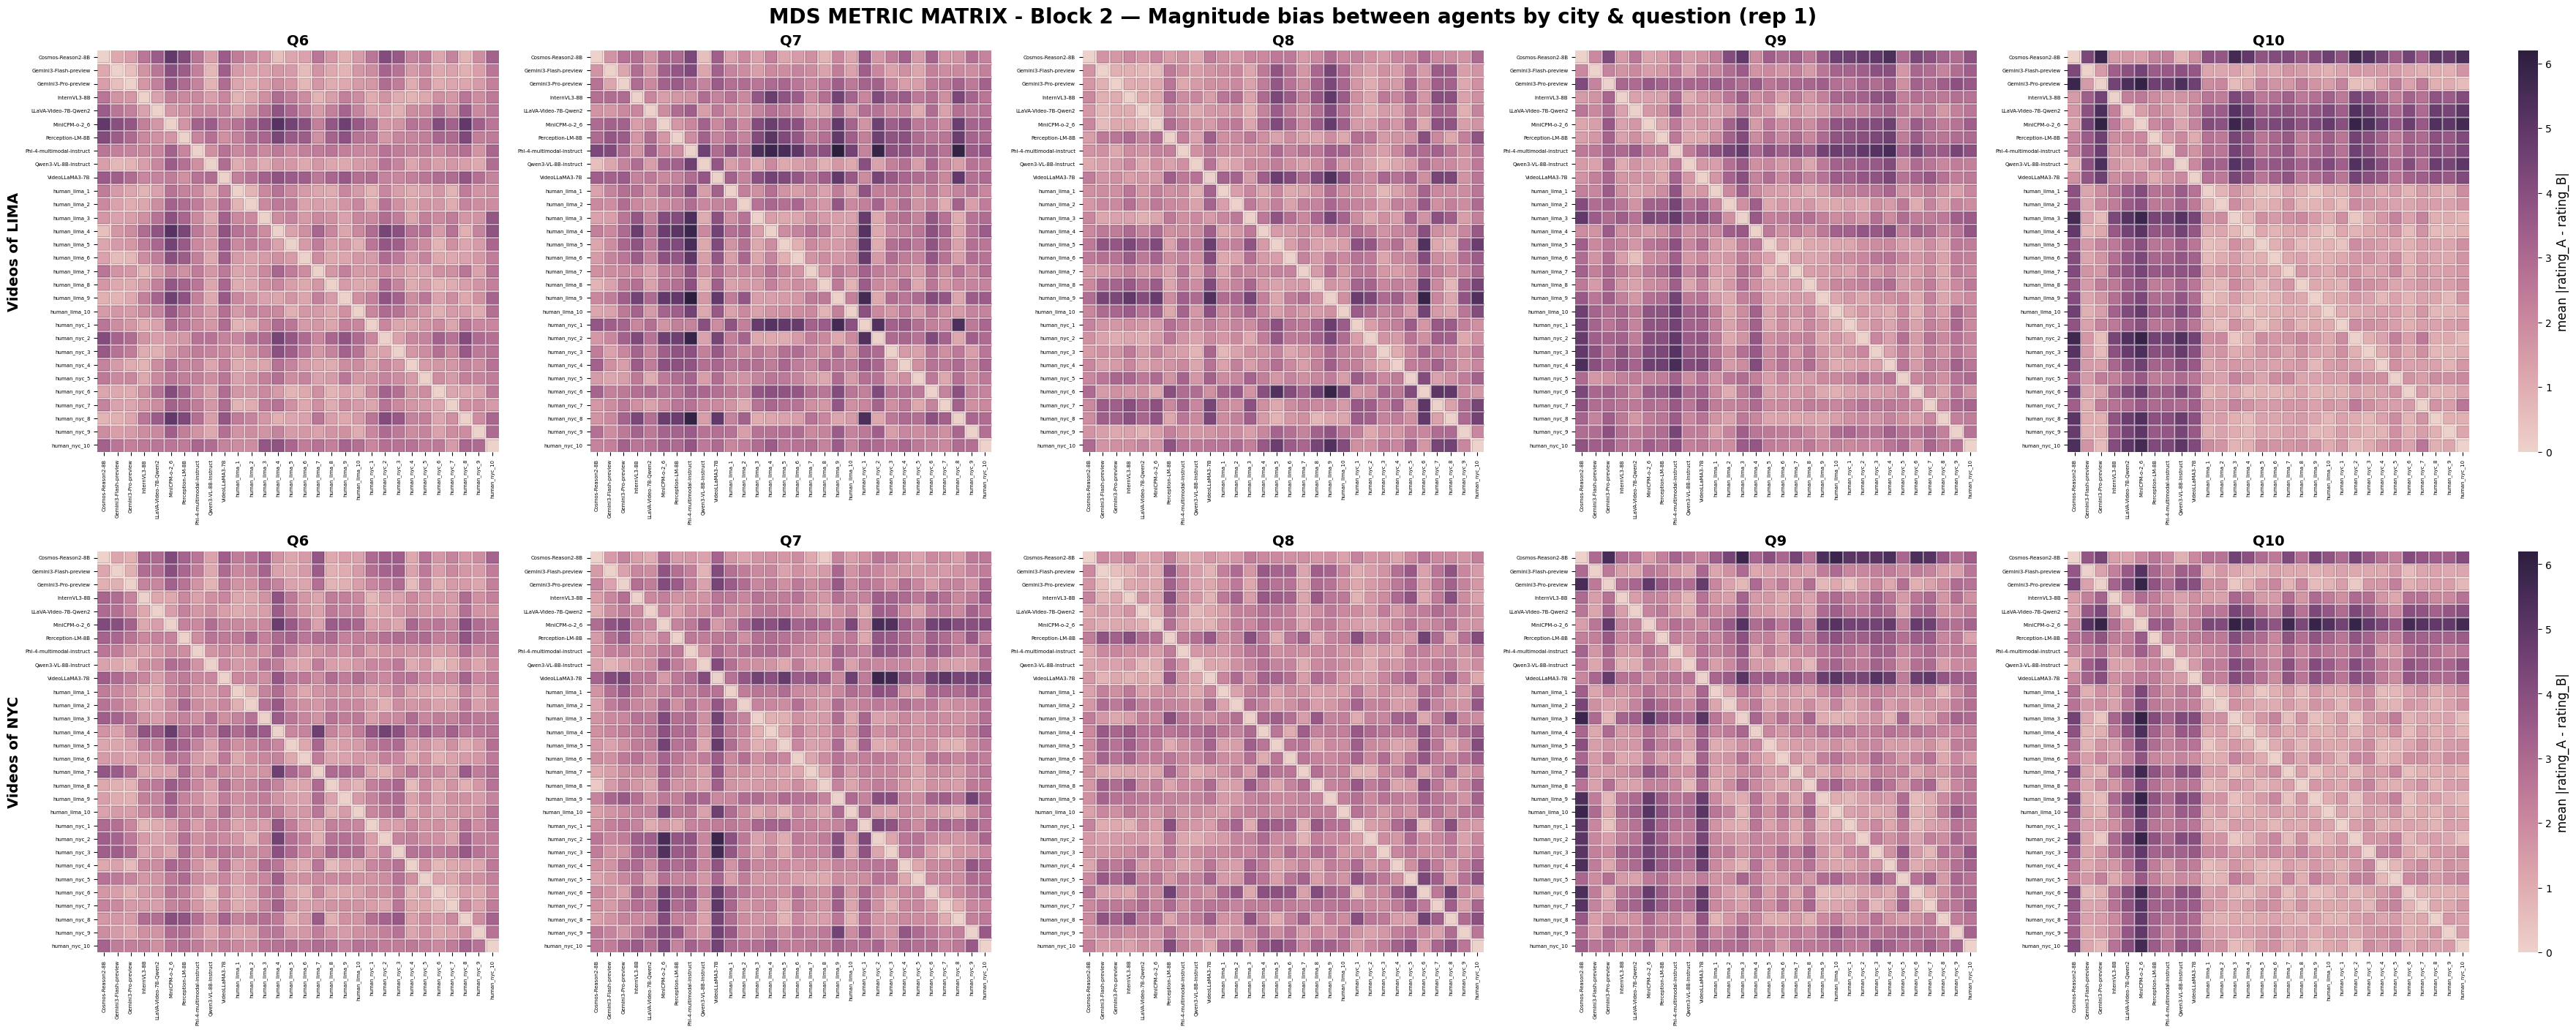

In [7]:
# --- PLOT: 2×5 grid of heatmaps (rows = city, cols = question) ---
labels = display_agent_names(agents)
nrows, ncols = len(regions), len(questions)

# constrained_layout = espacia los subplots Y ubica los colorbars por fila sin apretar la grilla.
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 7 * nrows),
                         squeeze=False, constrained_layout=True)

for i, region in enumerate(regions):
    for j, q in enumerate(questions):
        ax = axes[i, j]
        sns.heatmap(
            matrices[(region, q)],
            cmap=DIVERGING_CMAP,
            vmin=0,
            vmax=vmax,
            square=True,
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0,            # sin línea fija; la dibujamos con blended_grid
            cbar=False,              # un colorbar por fila (ver abajo)
            ax=ax,
        )
        # Costuras con gradiente tri-punto A -> blanco -> B segun las casillas aledañas.
        blended_grid(ax, matrices[(region, q)], DIVERGING_CMAP, vmin=0, vmax=vmax,
                     width=0.15, res=24, alpha=0.8)
        ax.set_title(f"Q{q}", weight="bold", fontsize=14)
        ax.tick_params(axis="x", labelsize=5, rotation=90)
        ax.tick_params(axis="y", labelsize=5, rotation=0)
        if j == 0:
            ax.set_ylabel(region, weight="bold", fontsize=14)

fig.suptitle("MDS METRIC MATRIX - Block 2 — Magnitude bias between agents by city & question (rep 1)", fontsize=20, weight="bold")

# Un colorbar por fila (arriba y abajo), cada uno a la derecha de SU fila.
sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=Normalize(vmin=0, vmax=vmax))
sm.set_array([])
for i in range(nrows):
    cbar = fig.colorbar(sm, ax=axes[i, :].tolist(), fraction=0.0195, pad=0.02)
    cbar.outline.set_visible(False)   # sin contorno negro
    cbar.set_label("mean |rating_A - rating_B|", fontsize=12)

RENDER_DPI = 300
plt.savefig("bias_mds_grid.svg", dpi=RENDER_DPI)
plt.savefig("bias_mds_grid.pdf", dpi=RENDER_DPI)
plt.show()

## MDS — embedding each agent as a point in 2D

We treat each per-`(city, question)` magnitude-difference matrix as a
**dissimilarity matrix** `δ` (lowercase delta) and recover a 2D configuration `X`
where each agent is one point and the layout reproduces `δ`.

Both solvers come from `sklearn.manifold.MDS` (SMACOF), starting from the same `δ`:

- **Metric MDS** (`metric=True`) — fits Euclidean distances directly to the
  dissimilarity values `δ`.
- **Non-metric MDS** (`metric=False`) — fits only the *rank order* of `δ` via
  isotonic regression, so it is robust to non-linear scaling of the
  dissimilarities.

Reported number = normalized stress (lower is better; <0.1 is a good fit). Both
solutions are only defined up to rotation/reflection, so absolute axis
orientation may differ between panels — only relative point positions matter.

In [8]:
# --- Iconos por agente (PNG en icons/) ---
# Asignación:
#   - VLMs  -> logo del fabricante (VLM_ICONS, confirmado mirando los PNG).
#   - Humanos Lima (rojo)  -> Red1..Red10  (por orden dentro del grupo).
#   - Humanos NYC  (azul)  -> Blue1..Blue10.
# El ícono va PELADO (sin círculo ni anillo). Si falta un archivo, cae al marcador.
import os
import re
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D

from scipy.ndimage import zoom as ndzoom

# icons/ está en la raíz del proyecto; tras `%cd ..` el cwd es la raíz. Robusto a src/ igual.
ICONS_DIR = next((d for d in ("icons", "../icons") if os.path.isdir(d)), "icons")

# >>> ESCALA GLOBAL DE LOS ÍCONOS <<<
ICON_SCALE = 1.0

# DPI de exportación. Escala los píxeles incrustados para reducir compresión en SVG/PDF:
#   zoom efectivo = target_px * ICON_SCALE * (RENDER_DPI/100) / img.shape[0]
# A RENDER_DPI=300 los íconos llevan 3× más píxeles con el mismo tamaño visual.
# Se capa zoom ≤ 1.0 para nunca upscalear (los círculos de humanos son PNGs pequeños
# y el upscaling los pixela).
RENDER_DPI = 300

VLM_ICONS = {
    "Cosmos-Reason2-8B": "Cosmos.png",
    "Gemini3-Flash-preview": "Gemini_Flash.png",
    "Gemini3-Pro-preview": "Gemini_Pro.png",
    "InternVL3-8B": "InternVL.png",
    "LLaVA-Video-7B-Qwen2": "LLM-Lab.png",     # lmms-lab
    "MiniCPM-o-2_6": "OpenBMB.png",
    "Perception-LM-8B": "Meta.png",          # Meta / PerceptionLM (logo restante)
    "Phi-4-multimodal-instruct": "Microsoft.png",
    "Qwen3-VL-8B-Instruct": "Qwen-3-01.png",
    "VideoLLaMA3-7B": "Damo.png",               # Alibaba DAMO
}


def _natural_key(name):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", name)]


def build_agent_icon_files(agents):
    """agente -> nombre de archivo en icons/. Humanos por orden de grupo (Red=Lima, Blue=NYC)."""
    lima = sorted([a for a in agents if "human" in a.lower() and "lima" in a.lower()], key=_natural_key)
    nyc = sorted([a for a in agents if "human" in a.lower() and "nyc" in a.lower()], key=_natural_key)
    files = dict(VLM_ICONS)
    for k, a in enumerate(lima, start=1):
        files[a] = f"Red{k}.png"
    for k, a in enumerate(nyc, start=1):
        files[a] = f"Blue{k}.png"
    return files


agent_icon_files = build_agent_icon_files(agents)


def _prep_icon(img, max_side=512):
    """Normaliza un ícono a un CUADRADO con relleno transparente (logo centrado, aspect
    preservado). Sólo bajo-muestrea los enormes a `max_side` con interpolación lineal.
    """
    img = np.asarray(img, float)
    if img.ndim == 2:                                   # gris -> RGBA
        img = np.dstack([img, img, img, np.ones_like(img)])
    if img.shape[2] == 3:                               # RGB -> RGBA
        img = np.dstack([img, np.ones(img.shape[:2])])
    h, w = img.shape[:2]
    side = max(h, w)
    if side > max_side:                                 # sólo achica los gigantes
        f = max_side / side
        img = np.clip(ndzoom(img, (f, f, 1), order=1), 0, 1)
        h, w = img.shape[:2]
        side = max(h, w)
    canvas = np.zeros((side, side, 4), float)           # cuadrado transparente
    y0, x0 = (side - h) // 2, (side - w) // 2
    canvas[y0:y0 + h, x0:x0 + w] = img
    return canvas


_icon_cache = {}


def load_agent_icon(agent):
    """Array RGBA CUADRADO del ícono del agente, o None si falta (-> fallback a marcador)."""
    if agent in _icon_cache:
        return _icon_cache[agent]
    fname = agent_icon_files.get(agent)
    img = None
    if fname:
        path = os.path.join(ICONS_DIR, fname)
        if os.path.exists(path):
            img = _prep_icon(plt.imread(path))
        else:
            print(f"[icon] falta {path} para {agent}")
    _icon_cache[agent] = img
    return img


def add_agent_icon(ax, x, y, img, target_px=30, ring=None, lw=2.0):
    """Dibuja el ícono en (x, y). Escala lineal: zoom = effective_px / img.shape[0],
    capeado a 1.0 para nunca upscalear íconos pequeños (evita pixelación en humanos).
    effective_px = target_px * ICON_SCALE * (RENDER_DPI/100) da más píxeles incrustados
    en SVG/PDF manteniendo el mismo tamaño visual al guardar con dpi=RENDER_DPI.
    """
    effective_px = target_px * ICON_SCALE * (RENDER_DPI / 100)
    zoom = min(effective_px / img.shape[0], 1.0)
    oi = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(oi, (x, y), frameon=False, pad=0.0, zorder=3)
    ax.add_artist(ab)
    return ab


class HandlerIcon(HandlerBase):
    """Legend handler que dibuja la imagen escalada a la altura del recuadro de la leyenda."""

    def __init__(self, img):
        self.img = img
        super().__init__()

    def create_artists(self, legend, orig, xd, yd, width, height, fontsize, trans):
        zoom = min(height / self.img.shape[0], 1.0)
        oi = OffsetImage(self.img, zoom=zoom)
        ab = AnnotationBbox(oi, (xd + width / 2, yd + height / 2), frameon=False,
                            xycoords=trans, box_alignment=(0.5, 0.5))
        return [ab]

In [9]:
# --- MDS solvers + shared plotting helper ---
from sklearn.manifold import ClassicalMDS
from pipeline.style import COLORS, build_agent_markers
from scipy.spatial.distance import pdist

# Same legend convention as the embedding plot (pipeline/stages/embed.py):
#   - color encodes the GROUP (lima / nyc / vlm)
#   - marker shape encodes the individual AGENT (build_agent_markers)
#   - one shared legend lists every agent with its (color, marker).
def _group_color(agent: str) -> str:
    a = agent.lower()
    if "human" in a:
        return COLORS["nyc"] if "nyc" in a else COLORS["lima"]
    return COLORS["vlm"]

agent_colors = {a: _group_color(a) for a in agents}
agent_markers = build_agent_markers(agents)          # stable marker per agent
agent_labels = display_agent_names(agents)           # display names, same order as `agents`


def _norm_stress(delta, coords):
    """Kruskal normalized stress-1 between input dissimilarities and embedding distances."""
    d = pdist(coords)                       # euclidean distances in the 2D embedding
    delta = np.asarray(delta, float)
    iu = np.triu_indices_from(delta, k=1)
    dd = delta[iu]
    m = ~np.isnan(dd)
    if m.sum() == 0 or np.sum(d[m] ** 2) == 0:
        return np.nan
    return np.sqrt(np.sum((d[m] - dd[m]) ** 2) / np.sum(d[m] ** 2))

def _mds(delta: np.ndarray, *, metric: bool, seed: int = 42):
    model = ClassicalMDS(
        n_components=2,
        metric="precomputed",
    )
    coords = model.fit_transform(np.asarray(delta, float))
    return coords, ("Stress: %.2f" % _norm_stress(delta, coords))


def metric_mds(delta: np.ndarray, seed: int = 42):
    """Metric MDS (fits distances to dissimilarity values)."""
    return _mds(delta, metric=True, seed=seed)


def _icon_legend(fig, marker_handles, **legend_kwargs):
    """Build a shared legend: icon (HandlerIcon) if the agent has one, else its marker."""
    handles, labels, hmap = [], [], {}
    for agent, lbl in zip(agents, agent_labels):
        img = load_agent_icon(agent)
        if img is not None:
            proxy = Line2D([], [], linestyle="none")
            hmap[proxy] = HandlerIcon(img)
        else:
            proxy = marker_handles.get(agent)
            if proxy is None:
                continue
        handles.append(proxy)
        labels.append(lbl)
    fig.legend(handles=handles, labels=labels, handler_map=hmap, **legend_kwargs)


def plot_mds_grid(solver, title, icon_px=20):
    """2x5 MDS grid per (region, question). Agents drawn as their icon (+ class ring),
    falling back to the marker when an icon is missing."""
    nrows, ncols = len(regions), len(questions)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)

    marker_handles = {}                      # solo para agentes sin ícono (fallback)
    for i, region in enumerate(regions):
        for j, q in enumerate(questions):
            ax = axes[i, j]
            coords, info = solver(matrices[(region, q)])
            ax.update_datalim(coords)        # los íconos no autoescalan: fijamos límites
            for k, agent in enumerate(agents):
                img = load_agent_icon(agent)
                if img is not None:
                    add_agent_icon(ax, coords[k, 0], coords[k, 1], img,
                                   target_px=icon_px, ring=agent_colors[agent])
                else:
                    sc = ax.scatter(
                        coords[k, 0], coords[k, 1],
                        color=agent_colors[agent],
                        marker=agent_markers[agent],
                        s=70,
                        alpha=0.9,
                        edgecolors="white",
                        linewidth=0.5,
                        zorder=3,
                    )
                    marker_handles.setdefault(agent, sc)
            ax.set_aspect("equal", adjustable="datalim")
            ax.autoscale_view()
            ax.margins(0.12)                 # aire para que los íconos del borde no se corten
            ax.set_title(f"Q{q}  ({info})", weight="bold", fontsize=12)
            ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
            ax.axvline(0, color="gray", lw=0.5, alpha=0.4)
            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.set_ylabel(region, weight="bold", fontsize=13)

    _icon_legend(
        fig, marker_handles,
        loc="center right",
        bbox_to_anchor=(1.03, 0.5),
        frameon=True,
        fontsize=10,
        title="Agent",
        title_fontproperties={"weight": "bold", "size": 13},
    )
    fig.suptitle(title, fontsize=20, weight="bold")
    fig.tight_layout(rect=(0, 0, 0.92, 1))

    plt.savefig("bias_mds_grid_plot.svg", dpi=RENDER_DPI)
    plt.savefig("bias_mds_grid_plot.pdf", dpi=RENDER_DPI)
    plt.show()

In [10]:
# Magnitude-difference matrix per region, aggregated over ALL questions (Q6–Q10).
matrices_all = {
    region: magnitude_diff_matrix(df_b2[df_b2["VIDEO_REGION"] == region], agents)
    for region in regions
}


def plot_all_mds_grid(solver, title, icon_px=30):
    """MDS por región (todas las preguntas). Cada agente = su ícono icons/<...>.png;
    si falta el ícono, cae al marcador de siempre.
    """
    nrows = len(regions)
    fig, axes = plt.subplots(1, nrows, figsize=(6.5 * nrows, 5.5), squeeze=False)

    marker_handles = {}                      # solo para agentes sin ícono (fallback)
    for i, region in enumerate(regions):
        ax = axes[0, i]
        delta = matrices_all[region]
        coords, _ = solver(delta)
        stress = _norm_stress(delta, coords)
        ax.update_datalim(coords)            # los íconos no autoescalan: fijamos límites
        for k, agent in enumerate(agents):
            img = load_agent_icon(agent)
            if img is not None:
                add_agent_icon(ax, coords[k, 0], coords[k, 1], img,
                               target_px=icon_px, ring=agent_colors[agent])
            else:
                sc = ax.scatter(
                    coords[k, 0], coords[k, 1],
                    color=agent_colors[agent],
                    marker=agent_markers[agent],
                    s=80,
                    alpha=0.9,
                    edgecolors="white",
                    linewidth=0.5,
                    zorder=3,
                )
                marker_handles.setdefault(agent, sc)
        ax.autoscale_view()
        ax.margins(0.12)                     # aire para que los íconos del borde no se corten
        ax.set_box_aspect(1)                 # CAJA cuadrada (no estirar el panel)
        ax.set_aspect("equal", adjustable="datalim")  # datos 1:1 dentro de la caja cuadrada
        ax.set_title(f"{region}  (stress={stress:.3f})", weight="bold", fontsize=13)
        ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
        ax.axvline(0, color="gray", lw=0.5, alpha=0.4)
        ax.grid(True, alpha=0.3)
        ax.set_ylabel(region, weight="bold", fontsize=12)

    # La figura es baja (5.5"): 30 entradas en 1 columna se solapan -> 2 columnas.
    _icon_legend(
        fig, marker_handles,
        loc="center left",
        bbox_to_anchor=(0.67, 0.5),
        ncol=2,
        frameon=True,
        fontsize=8,
        columnspacing=1.0,
        handletextpad=0.4,
        labelspacing=0.4,
        title="Agent",
        title_fontproperties={"weight": "bold", "size": 12},
    )
    fig.suptitle(title, fontsize=18, weight="bold")
    fig.tight_layout(rect=(0, 0, 0.65, 0.97))   # franja derecha reservada para la leyenda (2 cols)

    plt.savefig("bias_mds_all_plot.svg", dpi=RENDER_DPI)
    plt.savefig("bias_mds_all_plot.pdf", dpi=RENDER_DPI)
    plt.show()

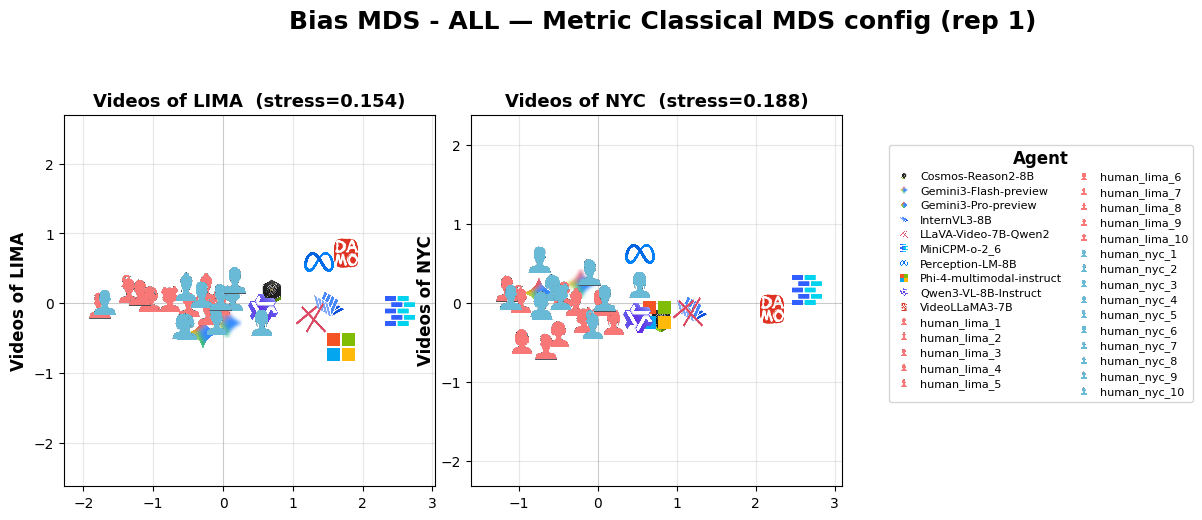

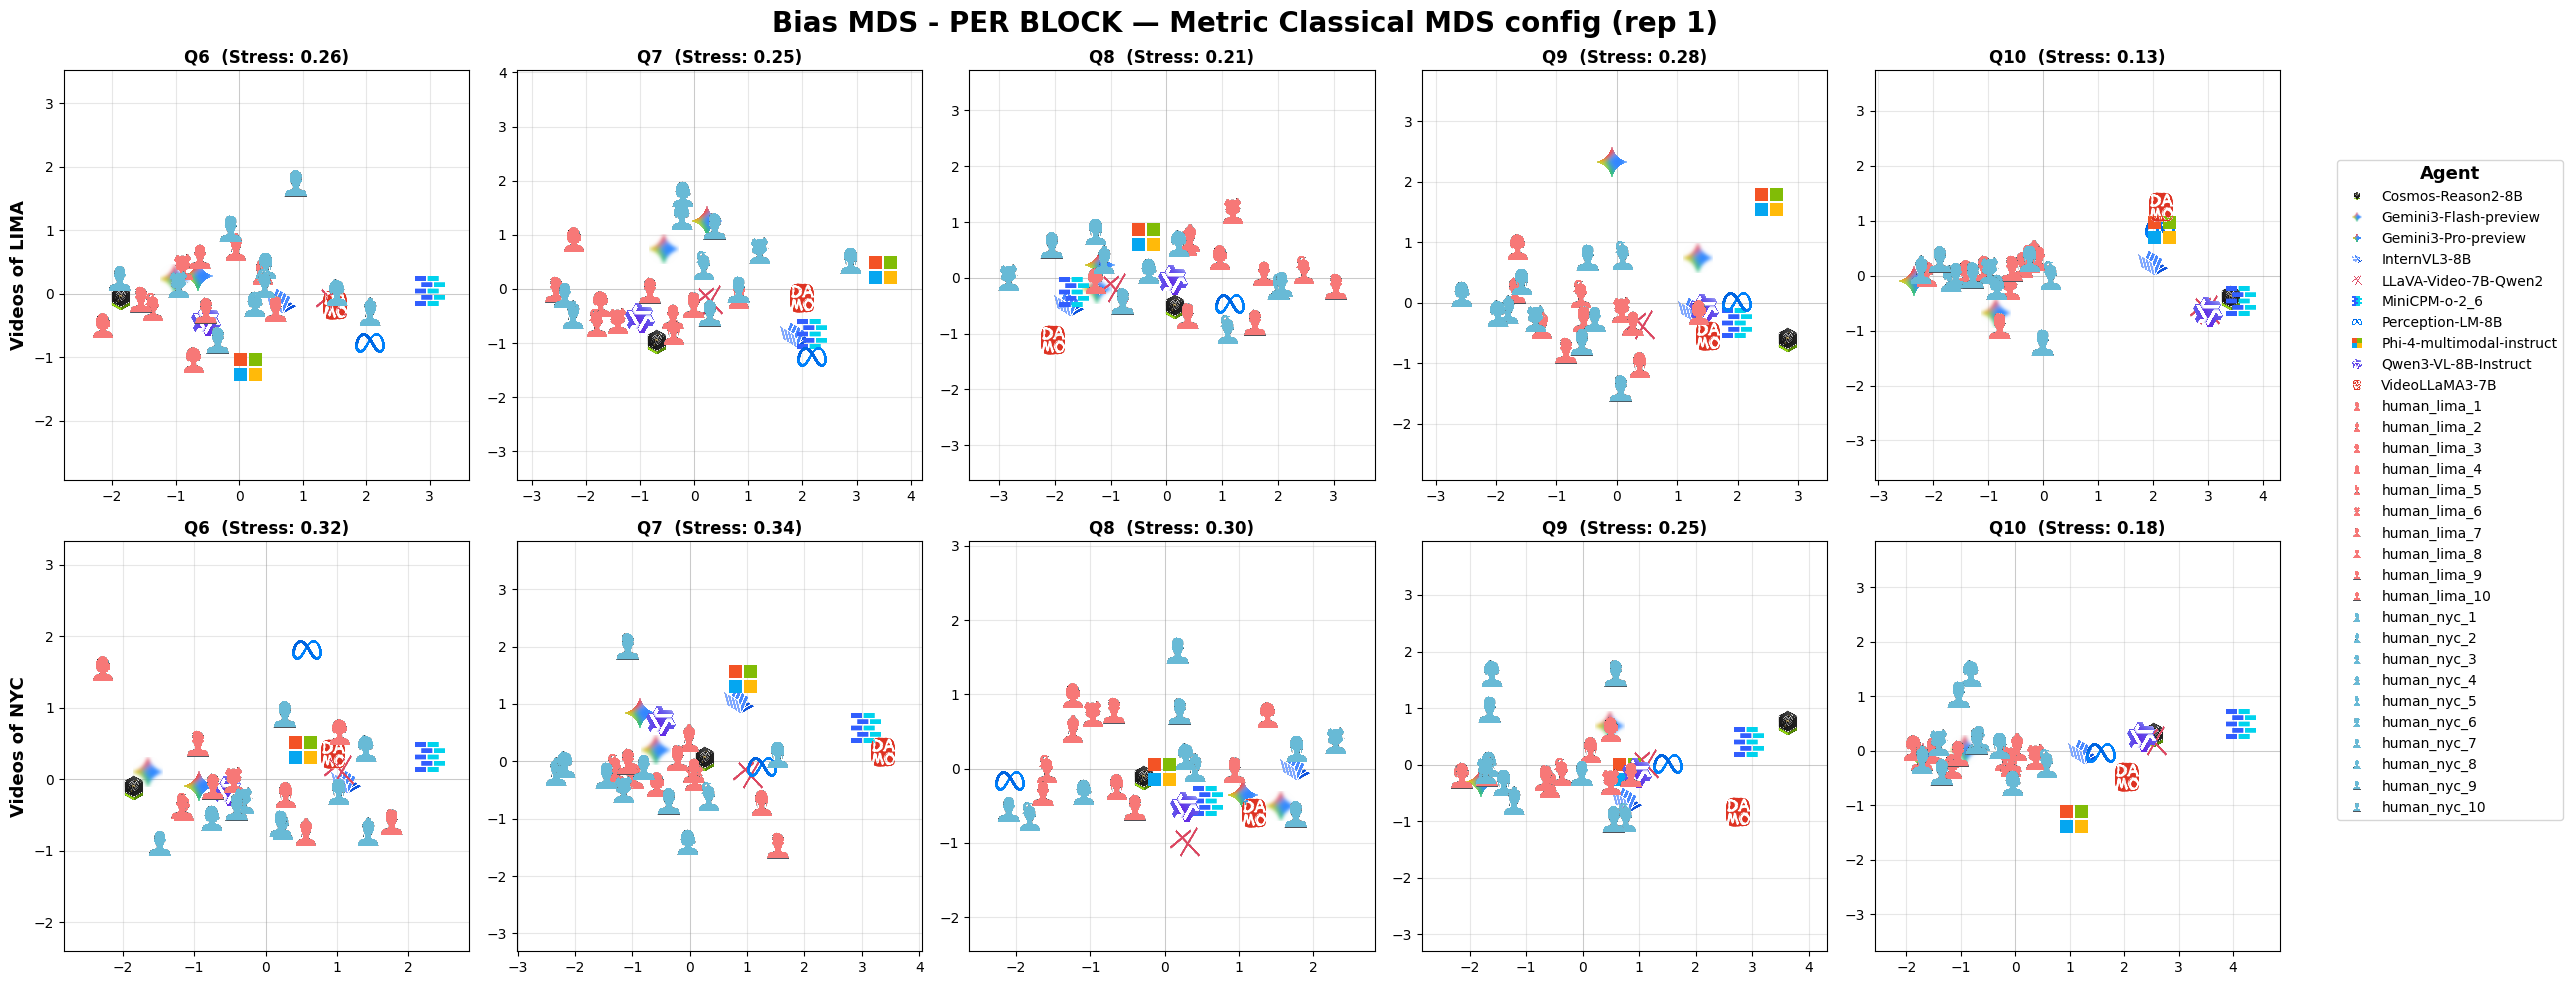

In [13]:
ICON_SIZE_PX = 7
plot_all_mds_grid(metric_mds, "Bias MDS - ALL — Metric Classical MDS config (rep 1)",icon_px=ICON_SIZE_PX)
plot_mds_grid(metric_mds, "Bias MDS - PER BLOCK — Metric Classical MDS config (rep 1)",icon_px=ICON_SIZE_PX)